<a href="https://colab.research.google.com/github/maneliaugust/CodeAlpha_Brazilian-E-Commerce-Public-Dataset-by-Olist/blob/main/Brazilian_E_Commerce_Public_Dataset_by_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [331]:
"""The Brazilian E-Commerce Public Dataset by Olist is a Kaggle dataset containing real order data from Olist,
a large Brazilian online retail platform. It records ~100k orders placed between 2016 and 2018 across multiple
marketplaces in Brazil, capturing the full journey from purchase to delivery and review.
"This analysis aims to explore customer purchasing behavior, delivery performance, and revenue patterns within
Olist's Brazilian e-commerce platform to uncover actionable business insights."""

'The Brazilian E-Commerce Public Dataset by Olist is a Kaggle dataset containing real order data from Olist,\na large Brazilian online retail platform. It records ~100k orders placed between 2016 and 2018 across multiple\nmarketplaces in Brazil, capturing the full journey from purchase to delivery and review.\n"This analysis aims to explore customer purchasing behavior, delivery performance, and revenue patterns within\nOlist\'s Brazilian e-commerce platform to uncover actionable business insights.'

In [332]:
print("=" * 40)
print("1. Importing Libraries")
print("=" * 40)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import datetime as dt
from scipy.stats import pearsonr, ttest_ind, chi2_contingency

sns.set(style="whitegrid")

1. Importing Libraries


In [333]:
print("=" * 40)
print("2. Loading the dataset & Data Overview")
print("=" * 40)

df = pd.read_csv('Brazilian_ecommerce.csv')
df.head()
df.describe()
df.info()

2. Loading the dataset & Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     113390 non-null  int64  
 1   order_id                       113390 non-null  object 
 2   order_item_id                  113390 non-null  int64  
 3   customer_id                    113390 non-null  object 
 4   customer_unique_id             113390 non-null  object 
 5   customer_zip_code_prefix       113390 non-null  int64  
 6   customer_city                  113390 non-null  object 
 7   customer_state                 113390 non-null  object 
 8   product_id                     113390 non-null  object 
 9   product_category_name          113390 non-null  object 
 10  product_name_lenght            113390 non-null  float64
 11  product_description_lenght     113390 non-null  floa

In [334]:
print("=" * 40)
print("3. Data Cleaning")
print("=" * 40)

#Convert Date Columns"
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])


print("\nExtracting Day, Month, Year and time")
print("-" * 40)

df["shipping_limit_year"] = df["shipping_limit_date"].dt.year
df["shipping_limit_month"] = df["shipping_limit_date"].dt.month
df["shipping_limit_day"] = df["shipping_limit_date"].dt.day
df["shipping_limit_day_name"] = df["shipping_limit_date"].dt.day_name()


df["purchase_day_name"] = df["order_purchase_timestamp"].dt.day_name()


df["order_approved_at_year"] = df["order_approved_at"].dt.year
df["order_approved_at_month"] = df["order_approved_at"].dt.month
df["order_approved_at_day"] = df["order_approved_at"].dt.day
df["order_approved_at_name"] = df["order_approved_at"].dt.day_name()


df["order_delivered_carrier_year"] = df["order_delivered_carrier_date"].dt.year
df["order_delivered_carrier_month"] = df["order_delivered_carrier_date"].dt.month
df["order_delivered_carrier_day"] = df["order_delivered_carrier_date"].dt.day
df["order_delivered_carrier_name"] = df["order_delivered_carrier_date"].dt.day_name()


df["order_delivered_customer_year"] = df["order_delivered_customer_date"].dt.year
df["order_delivered_customer_month"] = df["order_delivered_customer_date"].dt.month
df["order_delivered_customer_day"] = df["order_delivered_customer_date"].dt.day
df["order_delivered_customer_name"] = df["order_delivered_customer_date"].dt.day_name()


df["order_estimated_delivery_year"] = df["order_estimated_delivery_date"].dt.year
df["order_estimated_delivery_month"] = df["order_estimated_delivery_date"].dt.month
df["order_estimated_delivery_day"] = df["order_estimated_delivery_date"].dt.day
df["order_estimated_delivery_name"] = df["order_estimated_delivery_date"].dt.day_name()

#convert to period M for revenue trends and time series
df["purchase_year_month"] = pd.to_datetime(
    df["month/year_of_purchase"],
    format="%B-%Y"
).dt.to_period("M")

df

3. Data Cleaning

Extracting Day, Month, Year and time
----------------------------------------


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_delivered_carrier_name,order_delivered_customer_year,order_delivered_customer_month,order_delivered_customer_day,order_delivered_customer_name,order_estimated_delivery_year,order_estimated_delivery_month,order_estimated_delivery_day,order_estimated_delivery_name,purchase_year_month
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,Tuesday,2017,9,20,Wednesday,2017,9,29,Friday,2017-09
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,Wednesday,2017,7,13,Thursday,2017,7,26,Wednesday,2017-06
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,Wednesday,2018,6,4,Monday,2018,6,7,Thursday,2018-05
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,Wednesday,2017,8,9,Wednesday,2017,8,25,Friday,2017-08
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,Friday,2017,8,24,Thursday,2017,9,1,Friday,2017-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113385,113385,fdaf98feac227eb978d8f33f36e0231d,1,81ae83ce1a10af9f93fa3512bd9713b1,3d50a44231c2a153219cef76ee3e445d,22793,rio de janeiro,RJ,f739e9151702508b18f796c53005e5e9,moveis_decoracao,...,Thursday,2017,5,24,Wednesday,2017,5,22,Monday,2017-04
113386,113386,fe68b52db13993f58175fa589125d345,1,94203a446c1b46b5ac95b0aaf7221804,52a953541861bbb4b79b39df24e00243,13485,limeira,SP,f4135cbdece8245560f7be179533797a,eletronicos,...,Monday,2017,8,17,Thursday,2017,9,4,Monday,2017-08
113387,113387,fefacc66af859508bf1a7934eab1e97f,1,f48d464a0baaea338cb25f816991ab1f,459bef486812aa25204be022145caa62,29066,vitoria,ES,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,...,Friday,2018,8,15,Wednesday,2018,8,10,Friday,2018-07
113388,113388,ff701a7c869ad21de22a6994237c8a00,1,8f6d16c31abb30b7b4650272cb0014a3,ddb2249e0316d365ceae561c0f011bce,12280,cacapava,SP,5ff4076c0f01eeba4f728c9e3fa2653c,bebidas,...,Wednesday,2018,4,20,Friday,2018,4,30,Monday,2018-04


In [335]:
print("Creating New Features")
print("-" * 40)

# Delivery time
df["delivery_time"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days
df["delivery_time"] = df["delivery_time"].astype(int)


# Delivery delay
df["delivery_delay"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days


# Late delivery flag
df["is_late"] = df["delivery_delay"] > 0


# order_value (Sum of payments per order)
order_value = df.groupby("order_id", as_index=False)["payment_value"].sum()
order_value.rename(columns={"payment_value": "order_total_value"}, inplace=True)
df = df.merge(order_value, on="order_id", how="left")


#Count number of orders per customer
customer_orders = df.groupby("customer_unique_id")["order_id"].nunique().reset_index()
customer_orders.columns = ["customer_unique_id", "total_orders"]
df = df.merge(customer_orders, on="customer_unique_id", how="left")

df["repeat_customer"] = df["total_orders"] > 1

df

Creating New Features
----------------------------------------


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_estimated_delivery_month,order_estimated_delivery_day,order_estimated_delivery_name,purchase_year_month,delivery_time,delivery_delay,is_late,order_total_value,total_orders,repeat_customer
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,9,29,Friday,2017-09,7,-9,False,72.19,1,False
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,7,26,Wednesday,2017-06,15,-13,False,73.86,1,False
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,6,7,Thursday,2018-05,17,-3,False,83.23,1,False
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,8,25,Friday,2017-08,8,-16,False,75.07,1,False
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,9,1,Friday,2017-08,13,-8,False,72.19,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113385,113385,fdaf98feac227eb978d8f33f36e0231d,1,81ae83ce1a10af9f93fa3512bd9713b1,3d50a44231c2a153219cef76ee3e445d,22793,rio de janeiro,RJ,f739e9151702508b18f796c53005e5e9,moveis_decoracao,...,5,22,Monday,2017-04,35,2,True,136.04,2,True
113386,113386,fe68b52db13993f58175fa589125d345,1,94203a446c1b46b5ac95b0aaf7221804,52a953541861bbb4b79b39df24e00243,13485,limeira,SP,f4135cbdece8245560f7be179533797a,eletronicos,...,9,4,Monday,2017-08,6,-18,False,225.21,1,False
113387,113387,fefacc66af859508bf1a7934eab1e97f,1,f48d464a0baaea338cb25f816991ab1f,459bef486812aa25204be022145caa62,29066,vitoria,ES,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,...,8,10,Friday,2018-07,20,5,True,6922.21,1,False
113388,113388,ff701a7c869ad21de22a6994237c8a00,1,8f6d16c31abb30b7b4650272cb0014a3,ddb2249e0316d365ceae561c0f011bce,12280,cacapava,SP,5ff4076c0f01eeba4f728c9e3fa2653c,bebidas,...,4,30,Monday,2018-04,7,-10,False,169.36,1,False


4. Exploratory Data Analysis (EDA)

 Revenue Analysis
--------------------

Order Revenue:                                order_id  payment_value
0      00010242fe8c5a6d1ba2dd792cb16214          72.19
1      00018f77f2f0320c557190d7a144bdd3         259.83
2      000229ec398224ef6ca0657da4fc703e         216.87
3      00024acbcdf0a6daa1e931b038114c75          25.78
4      00042b26cf59d7ce69dfabb4e55b4fd9         218.04
...                                 ...            ...
95123  fffc94f6ce00a00581880bf54a75a037         343.40
95124  fffcd46ef2263f404302a634eb57f7eb         386.53
95125  fffce4705a9662cd70adb13d4a31832d         116.85
95126  fffe18544ffabc95dfada21779c9644f          64.71
95127  fffe41c64501cc87c801fd61db3f6244          55.79

[95128 rows x 2 columns]

Total Revenue: 19530503.34

Monthly Revenue


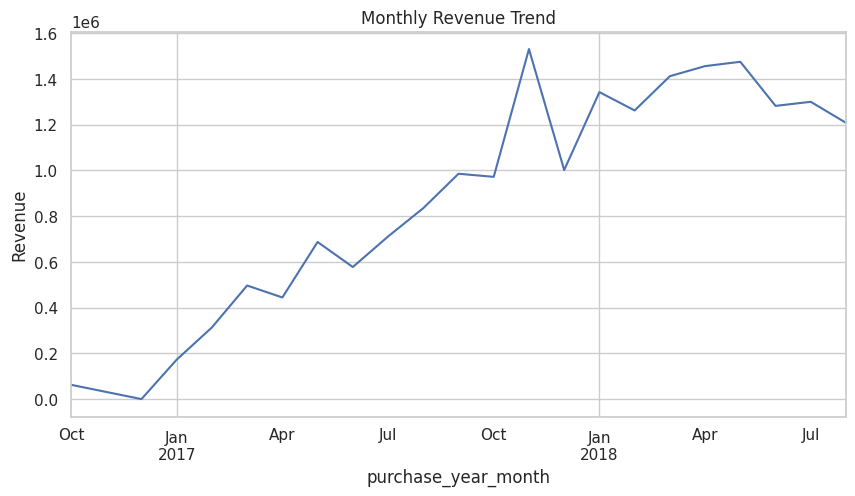


Revenue by State


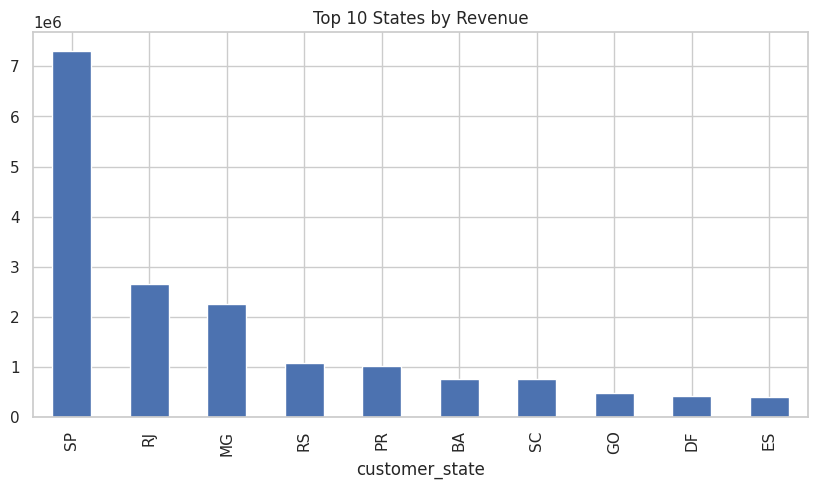


Revenue by Product Category


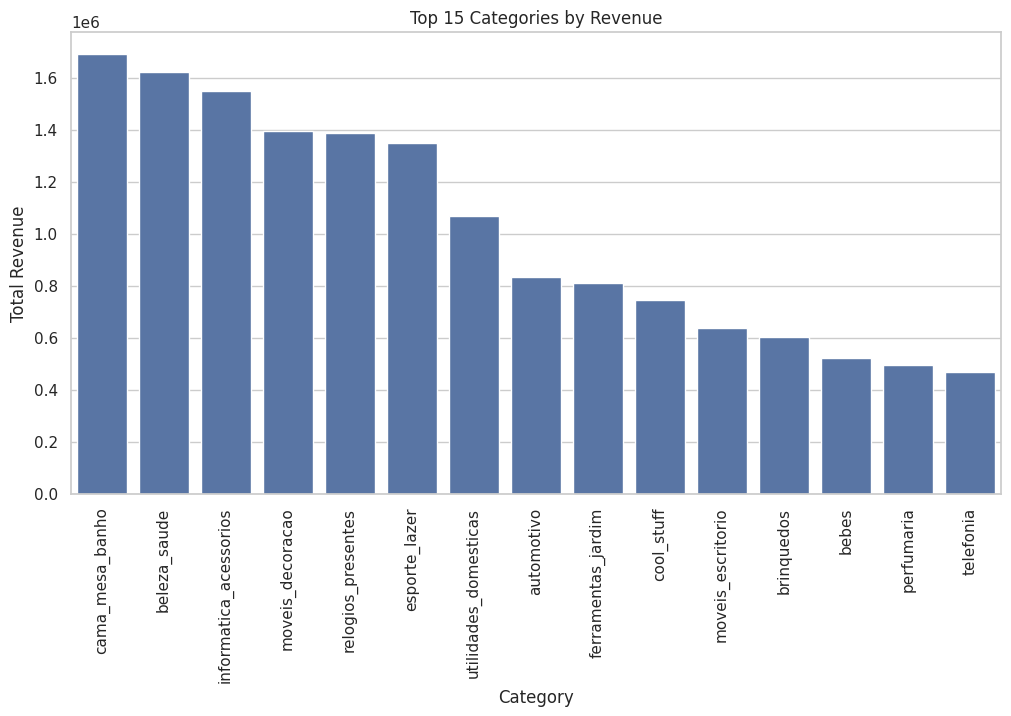


Revenue by Payment Type


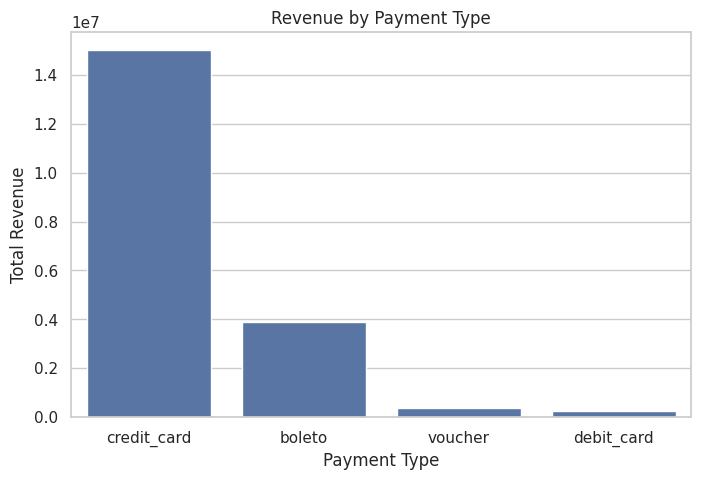

In [336]:
print("=" * 40)
print("4. Exploratory Data Analysis (EDA)")
print("=" * 40)

print("\n Revenue Analysis")
print("-" * 20)

#order_revenue
order_revenue = (
    df.groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)
print("\nOrder Revenue:", order_revenue)


#total revenue
total_revenue = df["payment_value"].sum()
print("\nTotal Revenue:", total_revenue)


#monthly revenue trend
monthly_revenue = df.groupby("purchase_year_month")["payment_value"].sum()
print("\nMonthly Revenue")

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()


#Revenue by State
state_revenue = df.groupby("customer_state")["payment_value"].sum().sort_values(ascending=False)
print("\nRevenue by State")

state_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Revenue")
plt.show()


#Revenue by Product Category
revenue_category = (
    df.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print("\nRevenue by Product Category")
plt.figure(figsize=(12,6))
sns.barplot(data=revenue_category.head(15),
            x="product_category_name",
            y="payment_value")

plt.title("Top 15 Categories by Revenue")
plt.xticks(rotation=90)
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.show()

#Revenue by Payment Type
revenue_payment = (
    df.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print("\nRevenue by Payment Type")
plt.figure(figsize=(8,5))
sns.barplot(data=revenue_payment,
            x="payment_type",
            y="payment_value")

plt.title("Revenue by Payment Type")
plt.ylabel("Total Revenue")
plt.xlabel("Payment Type")
plt.show()


Delivery Performance
----------------------------------------
Average delivery time: 12.01 days
Percentage of late deliveries: 6.53%


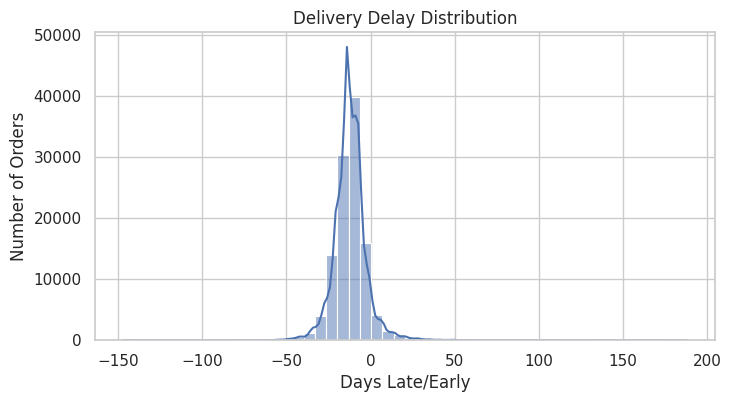

In [337]:
print("\nDelivery Performance")
print("-" * 40)

avg_delivery_time = df['delivery_time'].mean()
percent_late = df['is_late'].mean() * 100

print(f"Average delivery time: {avg_delivery_time:.2f} days")
print(f"Percentage of late deliveries: {percent_late:.2f}%")

# Delivery delay distribution
plt.figure(figsize=(8,4))
sns.histplot(df['delivery_delay'], bins=50, kde=True)
plt.title("Delivery Delay Distribution")
plt.xlabel("Days Late/Early")
plt.ylabel("Number of Orders")
plt.show()


Customer Behavior & Segmentation
----------------------------------------
Repeat purchase rate: 6.60%
Average order value: $143.26


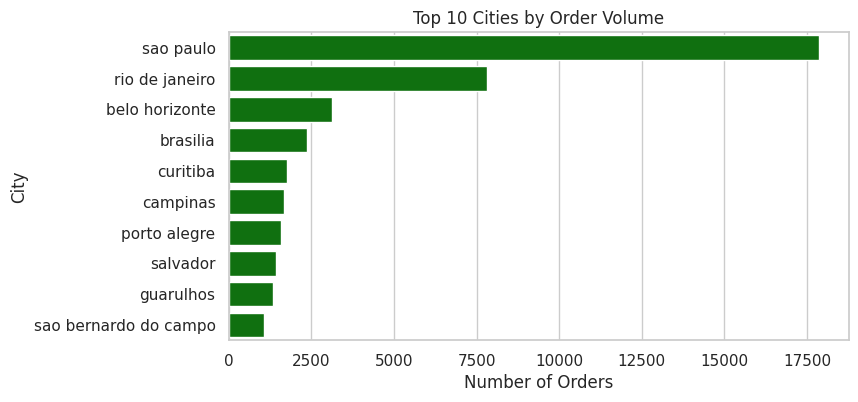


Option 1: RFM Segmentation
----------------------------------------


/tmp/ipykernel_1241/3750656281.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()


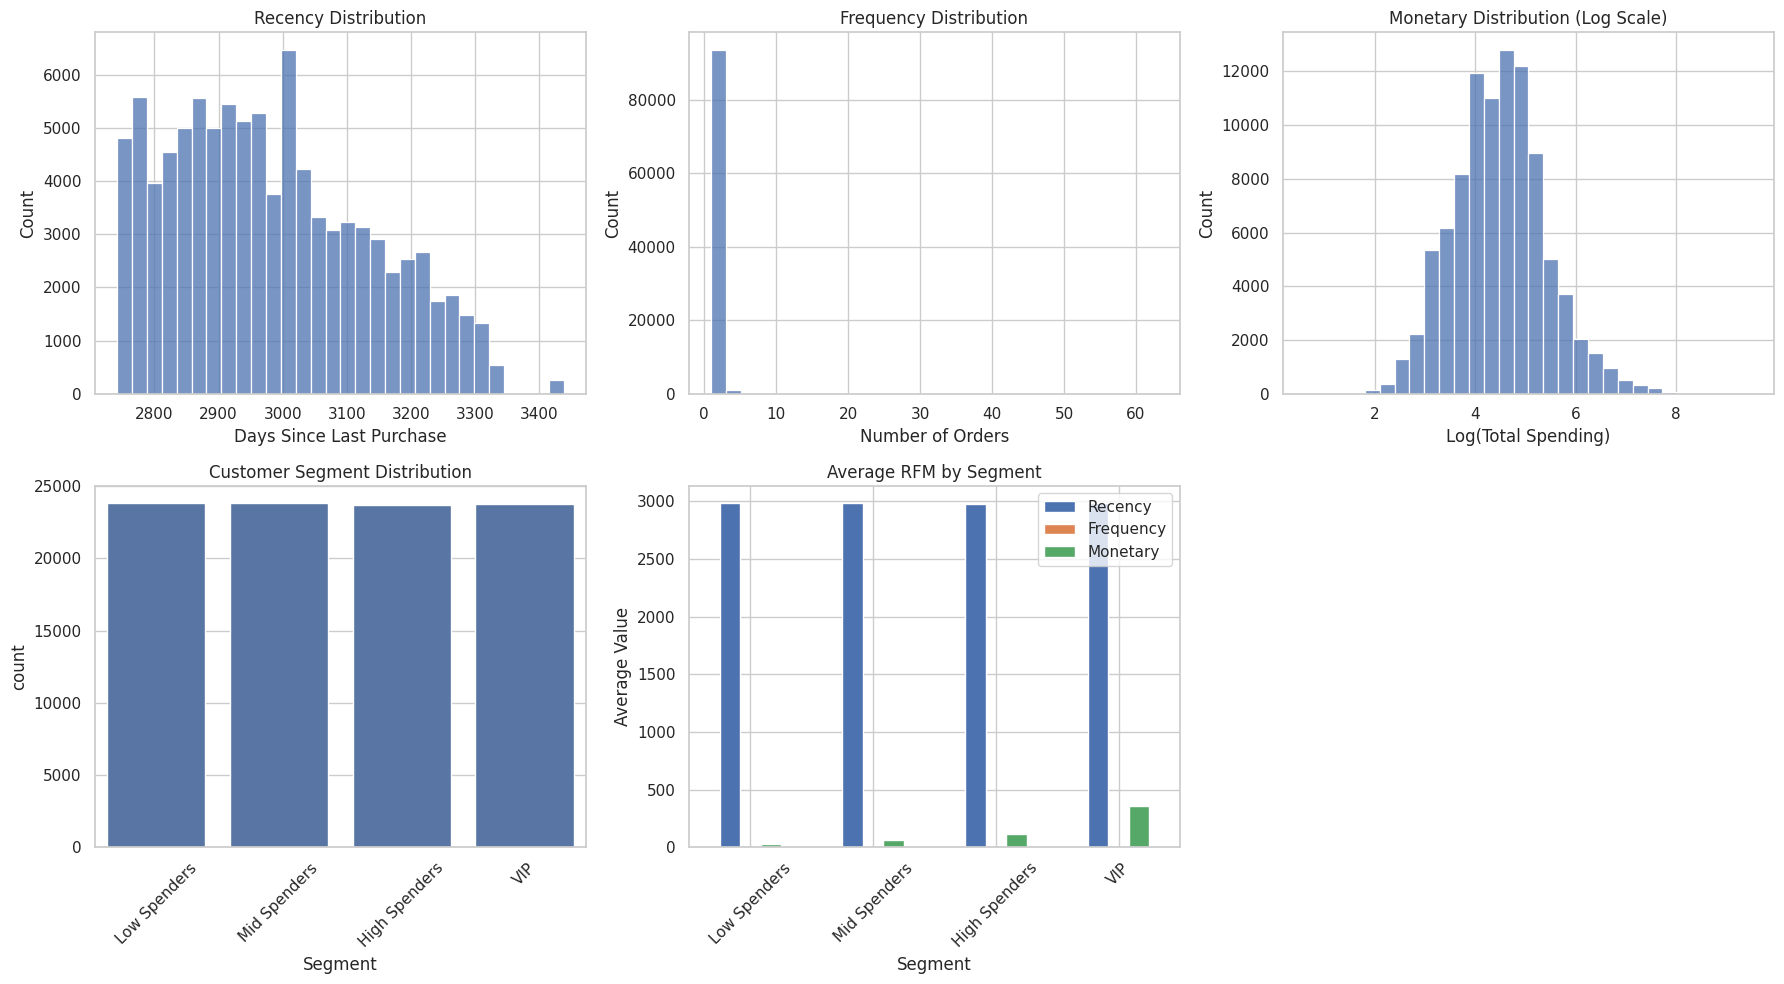


Option 2: K-Means Clustering
----------------------------------------


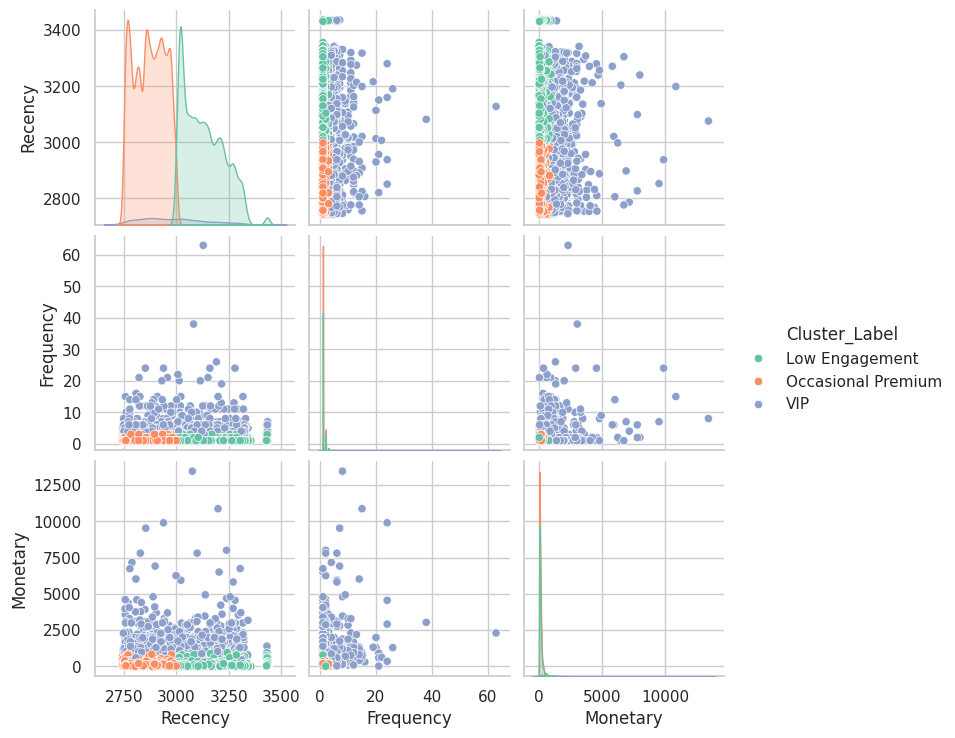

In [338]:
print("\nCustomer Behavior & Segmentation")
print("-" * 40)

# Repeat purchase rate
repeat_rate = df['repeat_customer'].mean() * 100
print(f"Repeat purchase rate: {repeat_rate:.2f}%")

# Average order value
df['order_total_value'] = df.groupby('order_id')['price'].transform('sum')
avg_order_value = df.groupby('customer_id')['order_total_value'].mean().mean()
print(f"Average order value: ${avg_order_value:.2f}")

# Top cities by order volume
top_cities = df.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_cities.values, y=top_cities.index, color='green')
plt.title("Top 10 Cities by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.show()

#=====================================================#
print("\nOption 1: RFM Segmentation")
print("-" * 40)
#=====================================================#
now = dt.datetime.now()
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (now - pd.to_datetime(x).max()).days,  # Recency
    'customer_id': 'count',  # Frequency
    'price': 'sum'           # Monetary
}).rename(columns={'order_purchase_timestamp':'Recency', 'customer_id':'Frequency', 'price':'Monetary'})

# Example: Segment by simple quantiles
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4, labels=['Low Spenders','Mid Spenders','High Spenders','VIP'])
rfm.head()


# Create figure with grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# -------------------------------
# 1️⃣ Recency Distribution
# -------------------------------
sns.histplot(rfm['Recency'], bins=30, ax=axes[0,0])
axes[0,0].set_title("Recency Distribution")
axes[0,0].set_xlabel("Days Since Last Purchase")

# -------------------------------
# 2️⃣ Frequency Distribution
# -------------------------------
sns.histplot(rfm['Frequency'], bins=30, ax=axes[0,1])
axes[0,1].set_title("Frequency Distribution")
axes[0,1].set_xlabel("Number of Orders")

# -------------------------------
# 3️⃣ Monetary Distribution (Log Scale for Clarity)
# -------------------------------
sns.histplot(np.log1p(rfm['Monetary']), bins=30, ax=axes[0,2])
axes[0,2].set_title("Monetary Distribution (Log Scale)")
axes[0,2].set_xlabel("Log(Total Spending)")

# -------------------------------
# 4️⃣ Customer Segment Count
# -------------------------------
sns.countplot(data=rfm, x='Segment', ax=axes[1,0])
axes[1,0].set_title("Customer Segment Distribution")
axes[1,0].set_xlabel("Segment")
axes[1,0].tick_params(axis='x', rotation=45)

# -------------------------------
# 5️⃣ Average RFM by Segment
# -------------------------------
segment_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

segment_summary.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Average RFM by Segment")
axes[1,1].set_ylabel("Average Value")
axes[1,1].tick_params(axis='x', rotation=45)

# Remove empty subplot (bottom right)
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()


#=====================================================#
print("\nOption 2: K-Means Clustering")
print("-" * 40)
#=====================================================#

# Features for clustering
X = rfm[['Recency','Frequency','Monetary']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Map cluster meaning (example)
cluster_map = {
    0: 'Low Engagement',
    1: 'Occasional Premium',
    2: 'VIP'
}
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_map)
rfm.head()

sns.pairplot(rfm, vars=['Recency','Frequency','Monetary'], hue='Cluster_Label', palette='Set2')
plt.show()


Seller Perfomance
----------------------------------------

seller_revenue


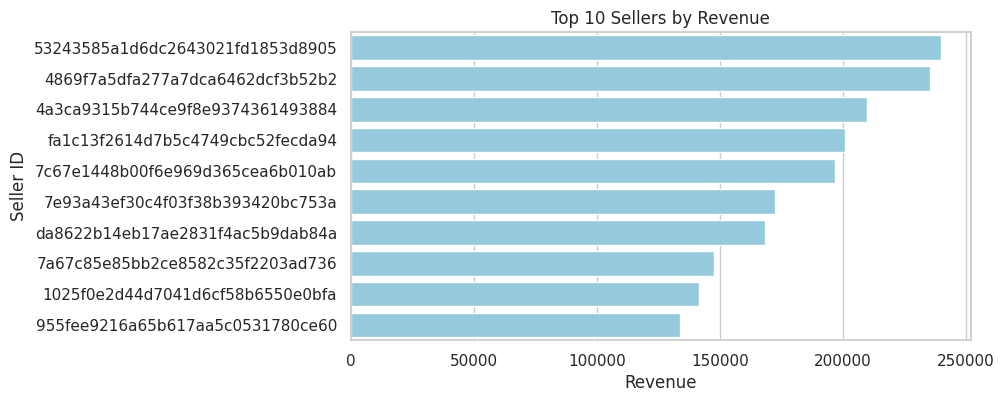


seller_delivery


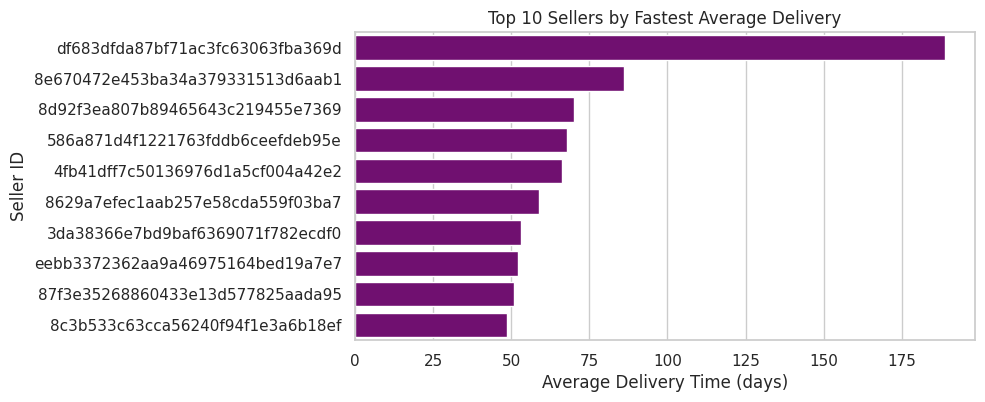

In [339]:
print("\nSeller Perfomance")
print("-" * 40)

# Top sellers by revenue
seller_revenue = df.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)
print("\nseller_revenue")
plt.figure(figsize=(8,4))
sns.barplot(x=seller_revenue.values, y=seller_revenue.index, color='skyblue')
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.show()


# Delivery speed by seller
seller_delivery = df.groupby('seller_id')['delivery_time'].mean().sort_values(ascending = False).head(10)
print("\nseller_delivery")
plt.figure(figsize=(8,4))
sns.barplot(x=seller_delivery.values, y=seller_delivery.index, color='purple')
plt.title("Top 10 Sellers by Fastest Average Delivery")
plt.xlabel("Average Delivery Time (days)")
plt.ylabel("Seller ID")
plt.show()

5. Correlation Analysis


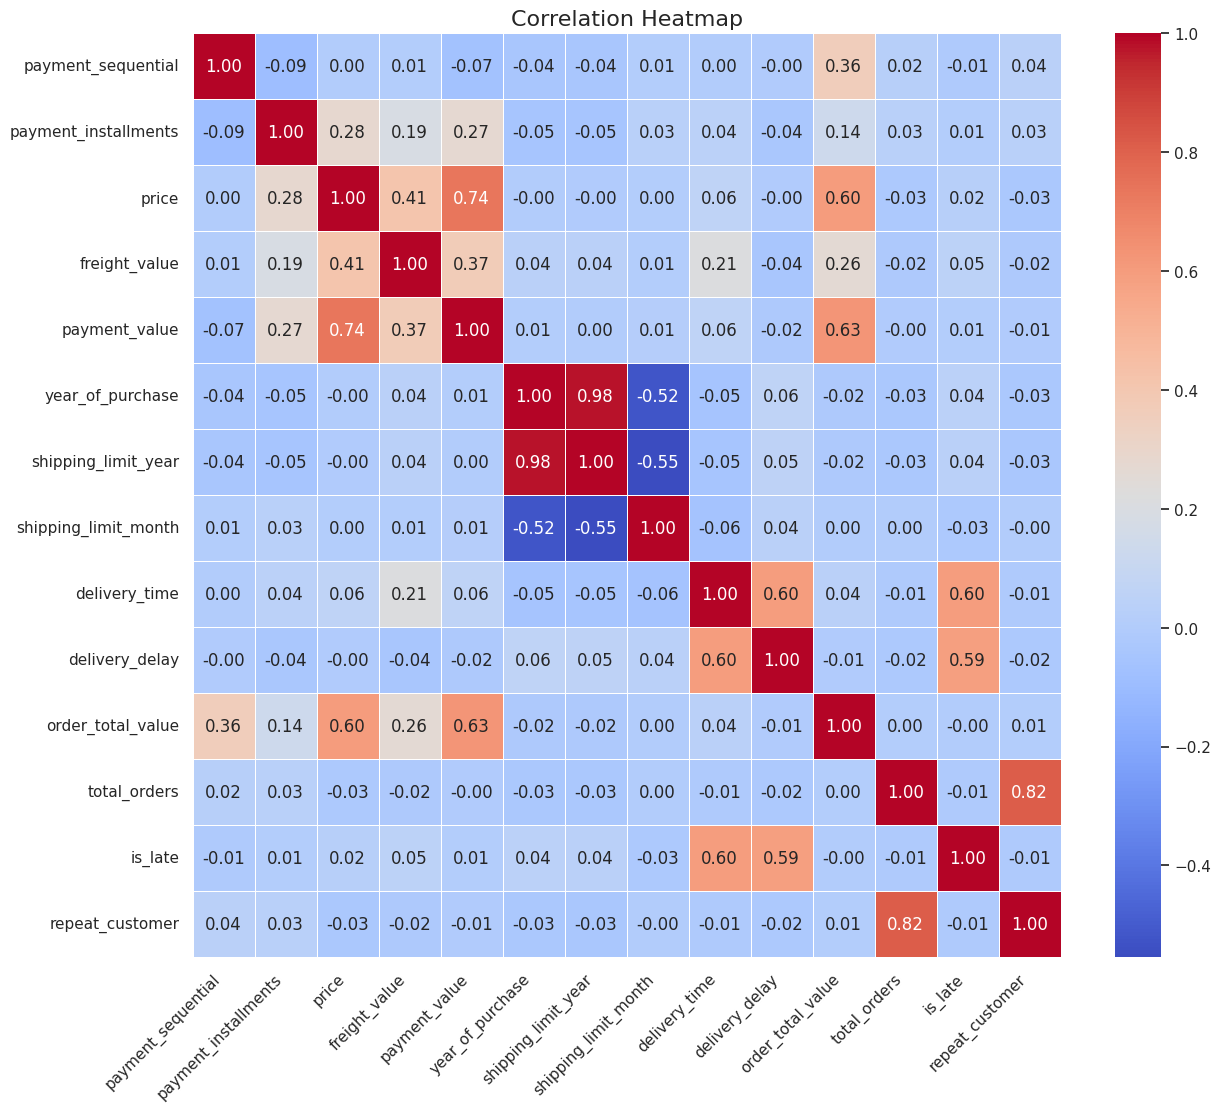

In [340]:
print("=" * 40)
print("5. Correlation Analysis")
print("=" * 40)

numeric_cols = ['payment_sequential', 'payment_installments', 'price', 'freight_value', 'payment_value',
 'year_of_purchase', 'shipping_limit_year', 'shipping_limit_month',
 'delivery_time', 'delivery_delay', 'order_total_value', 'total_orders',
 'is_late', 'repeat_customer']

corr = df[numeric_cols].corr()

plt.figure(figsize=(14,12))  # make it bigger
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.xticks(rotation=45, ha="right")  # rotate labels
plt.yticks(rotation=0)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

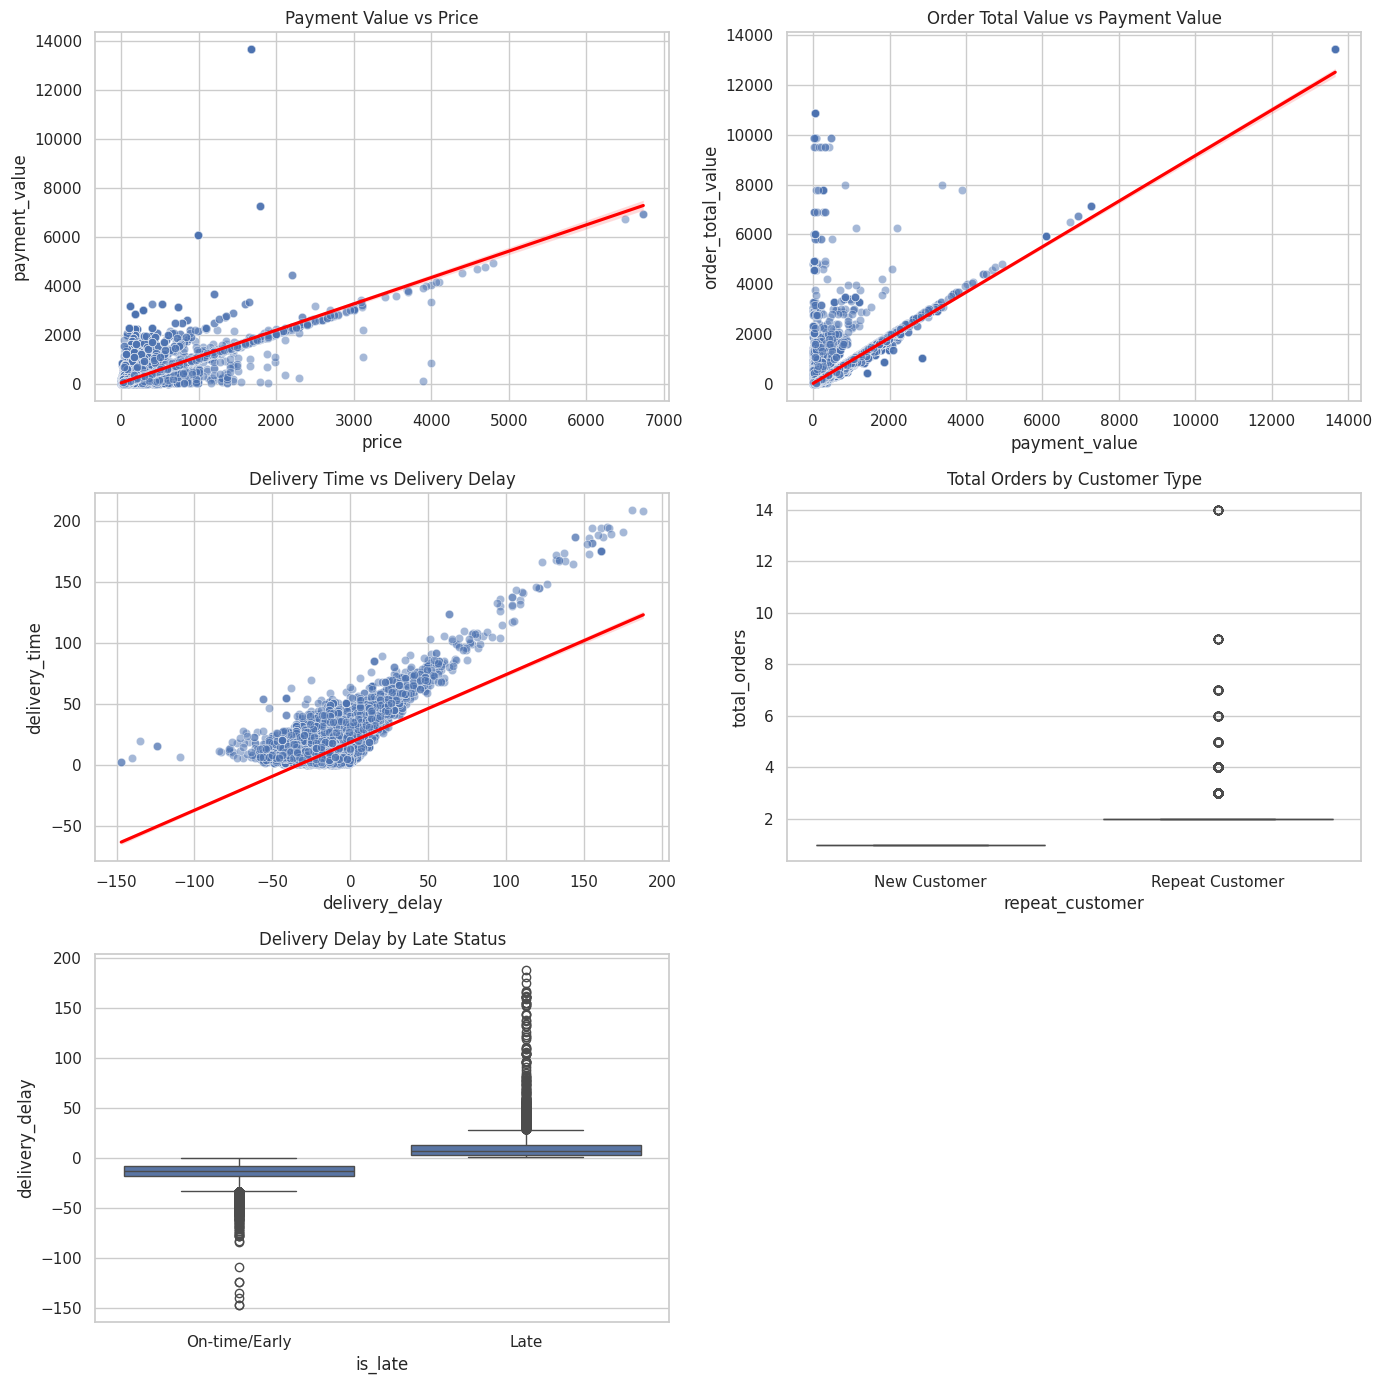

In [341]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Flatten axes for easy indexing
axes = axes.flatten()

# 1. payment_value vs price (scatter + regression)
sns.scatterplot(x='price', y='payment_value', data=df, alpha=0.5, ax=axes[0])
sns.regplot(x='price', y='payment_value', data=df, scatter=False, color='red', ax=axes[0])
axes[0].set_title("Payment Value vs Price")

# 2. order_total_value vs payment_value (scatter + regression)
sns.scatterplot(x='payment_value', y='order_total_value', data=df, alpha=0.5, ax=axes[1])
sns.regplot(x='payment_value', y='order_total_value', data=df, scatter=False, color='red', ax=axes[1])
axes[1].set_title("Order Total Value vs Payment Value")

# 3. delivery_time vs delivery_delay (scatter + regression)
sns.scatterplot(x='delivery_delay', y='delivery_time', data=df, alpha=0.5, ax=axes[2])
sns.regplot(x='delivery_delay', y='delivery_time', data=df, scatter=False, color='red', ax=axes[2])
axes[2].set_title("Delivery Time vs Delivery Delay")

# 4. total_orders vs repeat_customer (boxplot)
sns.boxplot(x='repeat_customer', y='total_orders', data=df, ax=axes[3])
axes[3].set_xticks([0,1])
axes[3].set_xticklabels(['New Customer', 'Repeat Customer'])
axes[3].set_title("Total Orders by Customer Type")

# 5. is_late vs delivery_delay (boxplot)
sns.boxplot(x='is_late', y='delivery_delay', data=df, ax=axes[4])
axes[4].set_xticks([0,1])
axes[4].set_xticklabels(['On-time/Early', 'Late'])
axes[4].set_title("Delivery Delay by Late Status")

# Remove the empty subplot (6th)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

6. Hypothesis Testing

Hypothesis 1. Delivery Delay → Order Status (Chi-SQ):
----------------------------------------
Chi-Square Statistic: 0.004260954838157574
p-value: 0.9479542589659714
Fail to reject H0 → Delivery delay does not significantly affect order status


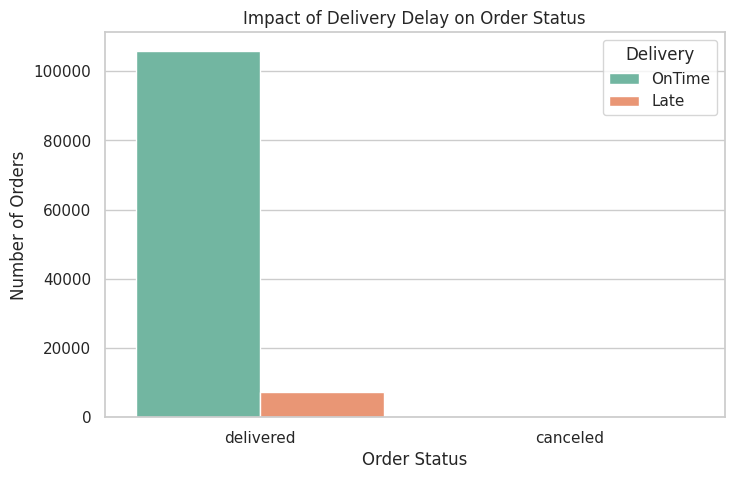


Hypothesis 2. Revenue by State (ANOVA):
----------------------------------------
F-statistic: 25.64
P-value: 0.0000
Reject H0 → Some states generate significantly higher revenue


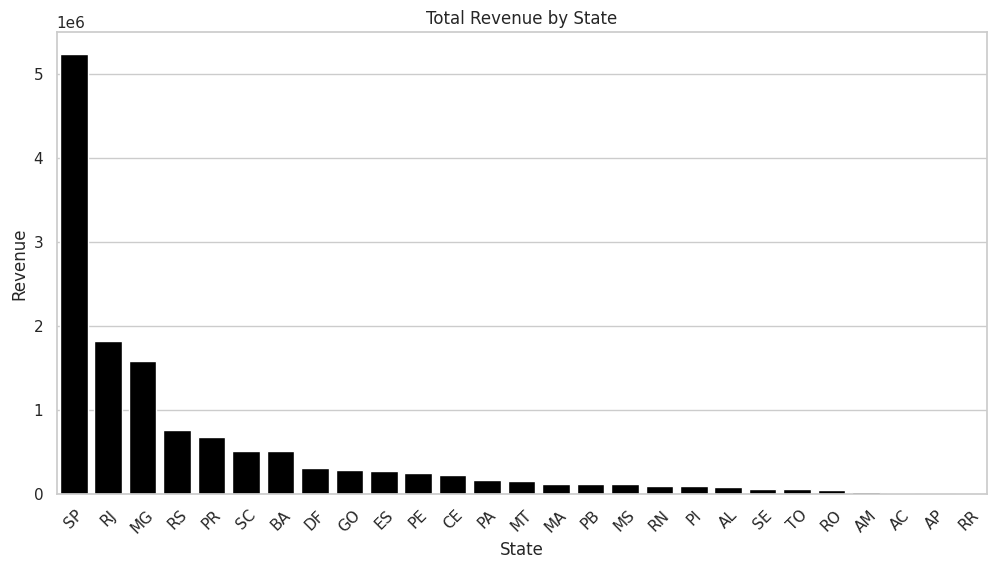

In [342]:
print("=" * 40)
print("6. Hypothesis Testing")
print("=" * 40)

#=====================================================#
print("\nHypothesis 1. Delivery Delay → Order Status (Chi-SQ):")
print("-" * 40)
#=====================================================#

#H0: Delivery delay does not affect order status.
#H1: Delivery delay affects order status.
#If p < 0.05, there’s statistical evidence that late deliveries influence the final status of an order.

# Assume 'delivery_delay' is number of days late (can be negative if early)
# Create a simple categorical variable: On Time vs Late
df['delay_category'] = df['delivery_delay'].apply(lambda x: 'Late' if x > 0 else 'OnTime')
df[['delay_category','order_status']].value_counts()


# Create a contingency table
contingency = pd.crosstab(df['delay_category'], df['order_status'])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 → Delivery delay significantly affects order status")
else:
    print("Fail to reject H0 → Delivery delay does not significantly affect order status")


plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='order_status',
    hue='delay_category',
    palette='Set2'
)

plt.title("Impact of Delivery Delay on Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.legend(title="Delivery")
plt.show()

#=====================================================#
print("\nHypothesis 2. Revenue by State (ANOVA):")
print("-" * 40)
#=====================================================#

#H0: Revenue is evenly distributed across states
#H1: Some states generate significantly higher revenue

# Group revenue by state
state_revenue = df.groupby('customer_state')['price'].sum().reset_index()
state_revenue

# Assuming you have order-level data with 'state' and 'price'
# Create a list of revenue per state for ANOVA
revenues_by_state = [group['price'].values for name, group in df.groupby('customer_state')]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*revenues_by_state)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 → Some states generate significantly higher revenue")
else:
    print("Fail to reject H0 → Revenue is evenly distributed across states")

# Sort states by revenue descending
state_revenue_sorted = state_revenue.sort_values(by='price', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=state_revenue_sorted,
    x='customer_state',
    y='price',
    color='black'
)
plt.title("Total Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


In [345]:
print("=" * 40)
print("7. Business Recommendations")
print("=" * 40)

""""States with highest revenue → Target ads & expand fulfillment.
VIP customers → Loyalty programs, exclusive discounts.
Delivery delays → Optimize logistics & warehouse distribution.
High-spend clusters → Personalized offers."""

7. Business Recommendations


'"States with highest revenue → Target ads & expand fulfillment.\nVIP customers → Loyalty programs, exclusive discounts.\nDelivery delays → Optimize logistics & warehouse distribution.\nHigh-spend clusters → Personalized offers.'